# K-Means Clustering Model Training

Train a K-Means clustering model for email spam detection (unsupervised).

## Notebook Structure
1. Import modules
2. Load dataset
3. Split data
4. Create and train pipeline
5. Evaluate clustering
6. Visualize results
7. Save model (.pkl)

### 1. Import modules

In [3]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn import metrics
import joblib

# Add src to path to import local modules
sys.path.append(os.path.abspath("../"))
from src.load_data import load_250K_email_dataset
from src.preprocess import clean_text
from src.config import MODEL_OUTPUT_DIR

### 2. Load dataset

In [4]:
df = load_250K_email_dataset()
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (322601, 2)


,text,label
0,wrong bill grace i ' ll forward original messa...,0
1,i have continued the hilcorp old ocean deal da...,0
2,several related issues have resulted in an inc...,0
3,one year rate for this one will be escapenumbe...,0
4,attached is the weekly deal report for escapen...,0


### 3. Split data

In [9]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

Train set: (258080,), Test set: (64521,)


### 4. Create and train pipeline

In [6]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(preprocessor=clean_text, max_features=5000, stop_words='english')),
    ('kmeans', KMeans(n_clusters=2, random_state=42, n_init=10))
])

pipeline.fit(X_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('kmeans', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",<function cle...t 0x1178038a0>
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


### 5. Evaluate clustering

In [7]:
train_clusters = pipeline.predict(X_train)

# Map clusters to labels (0: ham, 1: spam)
cluster_0_labels = y_train[train_clusters == 0]
cluster_1_labels = y_train[train_clusters == 1]

map_0 = cluster_0_labels.mode()[0]
map_1 = cluster_1_labels.mode()[0]

print(f"Cluster 0 maps to: {map_0}")
print(f"Cluster 1 maps to: {map_1}")

test_clusters = pipeline.predict(X_test)
test_preds = np.where(test_clusters == 0, map_0, map_1)

print(metrics.classification_report(y_test, test_preds))

Cluster 0 maps to: 0
Cluster 1 maps to: 1
              precision    recall  f1-score   support

           0       0.62      0.40      0.48     33691
           1       0.53      0.74      0.62     30830

    accuracy                           0.56     64521
   macro avg       0.58      0.57      0.55     64521
weighted avg       0.58      0.56      0.55     64521



### 6. Visualize results

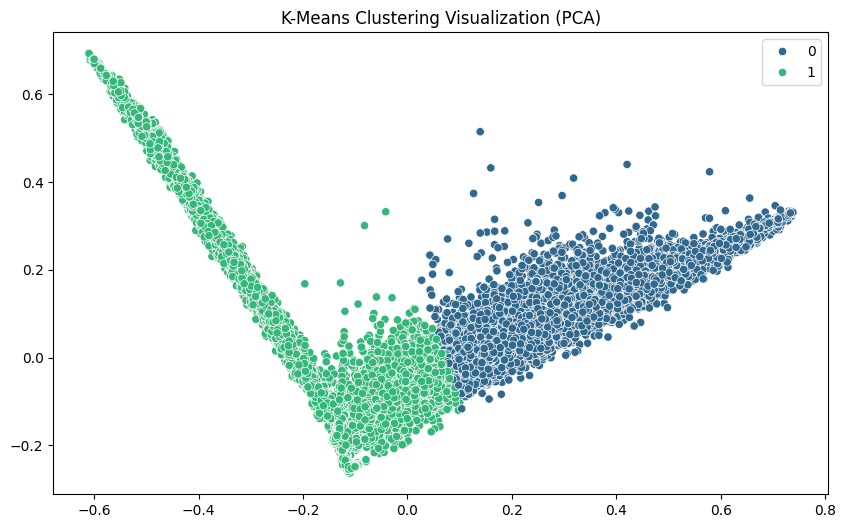

In [8]:
# Use PCA to reduce dimensions
tfidf_matrix = pipeline.named_steps['tfidf'].transform(X_test)
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(tfidf_matrix.toarray())

plt.figure(figsize=(10, 6))
sns.scatterplot(x=reduced_features[:, 0], y=reduced_features[:, 1], hue=test_preds, palette='viridis')
plt.title('K-Means Clustering Visualization (PCA)')
plt.show()

### 7. Save model (.pkl)

In [ ]:
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)
model_path = os.path.join(MODEL_OUTPUT_DIR, "kmeans_spam_model.pkl")
joblib.dump(pipeline, model_path)
print(f"Model saved to {model_path}")